In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Linear Regressison with simple Batch Gradient Descent

Learned Weights: [2.07786499 0.77104495]
Final Loss: 0.008754676300107492


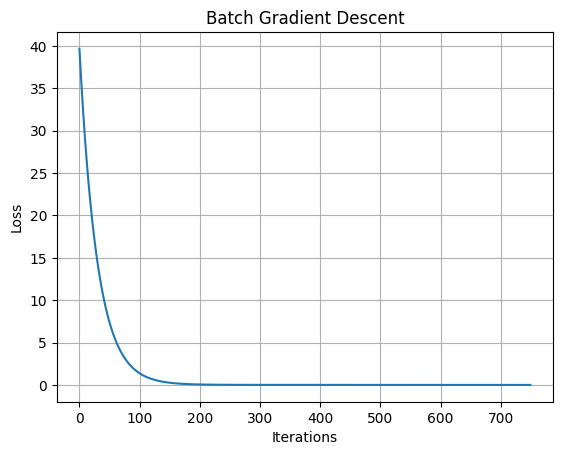

In [12]:
def objective(params, x, y):
    w, b = params
    pred = x @ np.array([w]) + b
    return np.mean((y-pred)**2)

def diff(func, w, x, y, epsilon=1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w0 = w.copy()
        w1 = w.copy()
        w0[i] += epsilon
        w1[i] -= epsilon
        grad[i] = (func(w0, x, y)-func(w1, x, y))/(2*epsilon)
    return grad

def step(w, x, y, lr = 0.001):
    grad = diff(objective, w, x, y)
    grad = lr * grad
    return w - grad

def linear_regression(x, y, T = 750):
    params = np.zeros(2)
    history = []
    for t in range(T):
        params = step(params, x, y)
        history.append(objective(params, x, y))
    return params, history

X = np.array([[1],[2],[3],[4]], dtype=float)
y = np.array([3,5,7,9], dtype=float)
w, history = linear_regression(X, y)
print("Learned Weights:", w)

print("Final Loss:", objective(w, X, y))

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent")
plt.grid(True)
plt.show()

### Linear Regression with Batch Gradient Descent and Pandas Dataframe

In [2]:
df = pd.DataFrame({

    "x1": [1,2,3,4, 67, 89, 342, -5587, 9005],

    "x2": [2,1,0,3, 7, 45, -5, 67, 123],

    "target": [5,6,7,10, 78, 809, -123, 456, -678],

})

Learned Parameters:
[-0.07937464  0.41677303  0.00915535]


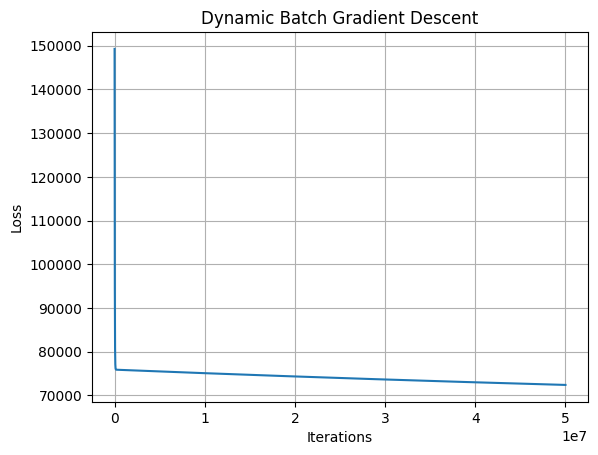

In [ ]:
def objective(params, x, y):
    w = params[:-1]
    b = params[-1]
    y0 = (x@w) + b
    return np.mean((y - y0)**2)
def diff(func, w, x,y, epsilon = 1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w0 = w.copy()
        w1 = w.copy()
        w0[i] +=epsilon
        w1[i] -= epsilon
        grad[i] = (func(w0, x,y)-func(w1, x,y))/(2*epsilon)
    return grad
def step(w, x, y, lr = 0.000000000001):
    dw = diff(objective, w, x,y)
    w = w- (lr*dw)
    return w
def linear_regression(x, y, T = 50000000):
    n_features = x.shape[1]
    params = np.zeros(n_features+1)

    history =[]
    for t in range(T):
        params = step(params, x, y)
        history.append(objective(params, x, y))
    return params, history
def train_dataframe(df, target_column):
    x = df.drop(columns=[target_column]).values
    y = df[target_column].values
    sol, history = linear_regression(x, y)
    return sol, history
params, history = train_dataframe(df, target_column="target")

print("Learned Parameters:")
print(params)

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Dynamic Batch Gradient Descent")
plt.grid(True)
plt.show()

### Linear Regression (with a huge dataset)

In [ ]:
np.random.seed(42)
N = 100000
x1 = np.random.normal(loc=100, scale=25, size=N)
x2 = np.random.normal(loc=0, scale=25, size=N)
x3 = np.random.normal(loc=-10, scale=15, size=N)

target = (3*x1 - 2*x2 -x3 + 5 + np.random.normal(loc=50, scale=5, size=N))
df = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3, "target": target})

Learned Parameters:
[ 3.51113469 -2.00019988 -1.06287317  0.06651512]


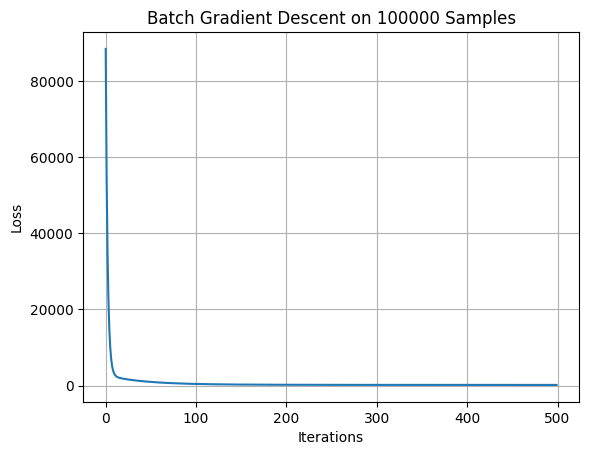

In [59]:
def objective(params, x, y):
    w = params[:-1]
    b = params[-1]
    y0 = (x@w) + b
    return np.mean((y-y0)**2)
def diff(func, w, x, y, epsilon=1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w0 = w.copy()
        w1 = w.copy()
        w0[i] += epsilon
        w1[i] -= epsilon
        grad[i] = (func(w0,x,y)-func(w1, x, y))/(2*epsilon)
    return grad
def step(w, x, y, lr =0.00001):
    grad = diff(objective, w, x, y)
    grad = lr*grad
    return w-grad
def linear_regression(x, y, T = 500):
    n_features = x.shape[1]
    params = np.zeros(n_features+1)
    history = []
    for t in range(T):
        params = step(params, x, y)
        history.append(objective(params, x, y))
    return params, history

x = df.drop(columns=["target"]).values
y = df["target"].values

sol, history = linear_regression(x,y)
print("Learned Parameters:")
print(sol)

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent on 100000 Samples")
plt.grid(True)

plt.show()

### Linear Regression on the huge dataset with SGD

In [43]:
np.random.seed(42)
N = 100000
x1 = np.random.normal(loc=100, scale=25, size=N)
x2 = np.random.normal(loc=0, scale=25, size=N)
x3 = np.random.normal(loc=-10, scale=15, size=N)

target = (3*x1 - 2*x2 -x3 + 5 + np.random.normal(loc=50, scale=5, size=N))
df = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3, "target": target})

Learned Parameters:
[ 3.5117576  -1.94975229 -0.96320817  0.054904  ]


()

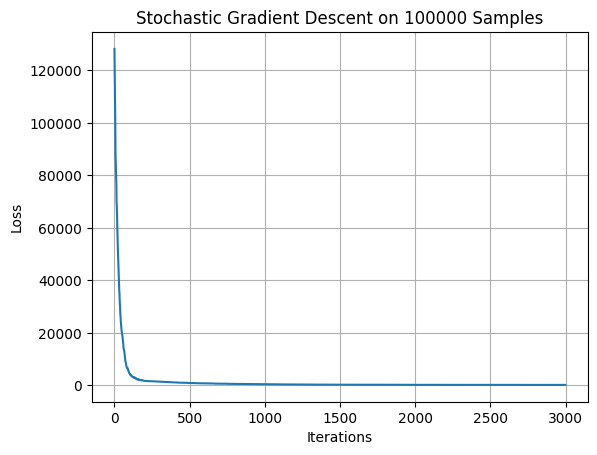

In [66]:
def objective(params, x, y):
    w = params[:-1]
    b = params[-1]
    y0 = (x@w) + b
    return np.mean((y - y0)**2)
def diff(func, w, x, y, epsilon=1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w0 = w.copy()
        w1 = w.copy()
        w0[i] += epsilon
        w1[i] -= epsilon
        grad[i] = (func(w0, x, y)-func(w1, x, y))/(2*epsilon)
    return grad
def SGD_step(w, x, y, lr = 0.000001):
    idx = np.random.randint(0, len(x))
    x_i = x[idx:idx+1]
    y_i = y[idx:idx+1]
    grad = diff(objective, w, x_i, y_i)
    step = lr*grad
    return w-step
def SGD_LR(x, y, T = 3000):
    n_features = x.shape[1]
    params = np.zeros(n_features+1)
    history=[]
    for t in range(T):
        params = SGD_step(params, x, y)
        history.append(objective(params, x, y))
    return params, history

x = df.drop(columns=["target"]).values
y = df["target"].values

sol, history = SGD_LR(x,y)
print("Learned Parameters:")
print(sol)

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Stochastic Gradient Descent on 100000 Samples")
plt.grid(True)

plt.show
()

### Stochastic Gradient Descent on Linear Regression BUT... with... MOMENTUM!!!

In [67]:
n = 1_000_000
np.random.sample(42)

x1 = np.random.normal(loc=100, scale=25, size=N)
x2 = np.random.normal(loc=0, scale=25, size=N)
x3 = np.random.normal(loc=-10, scale=15, size=N)

target = (3*x1 - 2*x2 -x3 + 5 + np.random.normal(loc=50, scale=5, size=N))
df = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3, "target": target})

Learned Parameters:
[ 3.51022267 -1.99559635 -1.05936941  0.06694125]


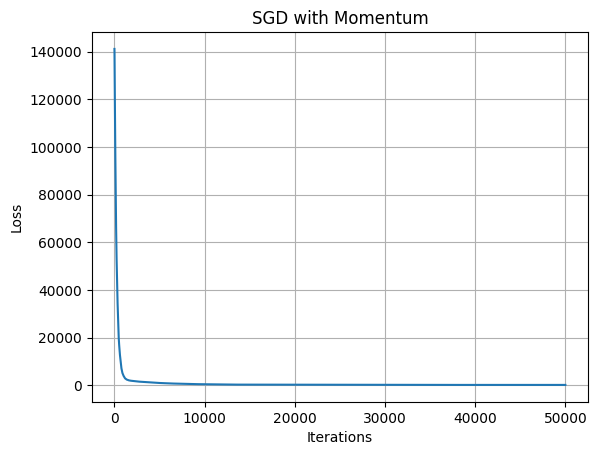

In [78]:
def objective(params, x, y):
    w = params[:-1]
    b= params[-1]
    y0 = (x@w)+b
    return np.mean((y-y0)**2)
def diff(func, w, x, y, epsilon = 1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w0 = w.copy()
        w1 = w.copy()
        w0[i] += epsilon
        w1[i] -= epsilon
        grad[i] = (func(w0, x, y)-func(w1, x, y))/(2*epsilon)
    return grad
def SGD_momentum_step(w, x, y, velocity, beta = 0.9, lr = 0.00000001):
    idx = np.random.randint(0, len(x))
    x_i = x[idx:idx+1]
    y_i = y[idx:idx+1]
    grad = diff(objective, w, x_i, y_i)
    velocity = (velocity*beta + lr*grad)
    return w - velocity, velocity
def SGD_LR(x, y, T= 50000):
    num = x.shape[1]
    params = np.zeros(num+1)
    velocity = np.zeros_like(params)
    history = []
    for t in range(T):
        params, velocity = SGD_momentum_step(params, x, y, velocity)
        history.append(objective(params, x, y))
    return params, history
x = df.drop(columns=["target"]).values
y = df["target"].values

sol, history = SGD_LR(x, y)
print("Learned Parameters:")
print(sol)

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("SGD with Momentum")
plt.grid(True)
plt.show()

### Stochastic Gradient Descent on Linear Regression BUT... with... MOMENTUM + ADAM!!!

Learned Parameters:
[ 3.04375169 -2.06255947 -1.04738127 55.10066207]


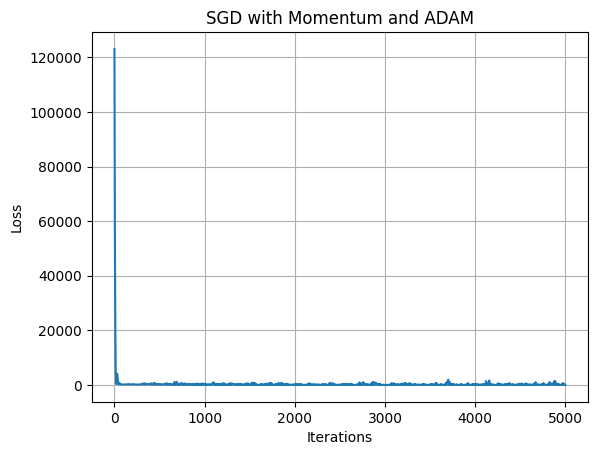

In [89]:
def objective(params, x, y):
    w = params[:-1]
    b = params[-1]
    y0 = (x@w)+b
    return np.mean((y-y0)**2)
def diff(func, w, x, y, epsilon=1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w0 = w.copy()
        w1 = w.copy()
        w0[i] += epsilon
        w1[i] -= epsilon
        grad[i] = (func(w0,x,y)-func(w1,x,y))/(2*epsilon)
    return grad
def ADAM_SGD_step(w, x, y, m, v, t, beta = 0.9, alpha = 0.99, lr = 0.215, epsilon = 1e-8):
    idx = np.random.randint(0, len(x))
    x_i = x[idx:idx+1]
    y_i = y[idx:idx+1]
    grad = diff(objective, w, x_i,y_i)
    m = ((beta*m) + ((1-beta)*grad))
    v = ((alpha*v) + ((1-alpha)*(grad**2)))
    m_hat = m/(1-(beta**t))
    v_hat = v/(1-(alpha**t))
    w = w - ((lr*m_hat)/((np.sqrt(v_hat)+epsilon)))
    return w, m, v
def ADAM_LR(x,y,T=5000):
    n_features = x.shape[1]
    params = np.zeros(n_features + 1)
    m = np.zeros_like(params)
    v = np.zeros_like(params)
    history = []
    for t in range(1, T + 1):
        params, m, v = ADAM_SGD_step(params,x,y,m,v,t)
        history.append(objective(params, x, y))
    return params, history
x = df.drop(columns=["target"]).values
y = df["target"].values

sol, history = ADAM_LR(x, y)
print("Learned Parameters:")
print(sol)

plt.plot(history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("SGD with Momentum and ADAM")
plt.grid(True)
plt.show()